### IMPORTS

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

### REVISTAS

#### General

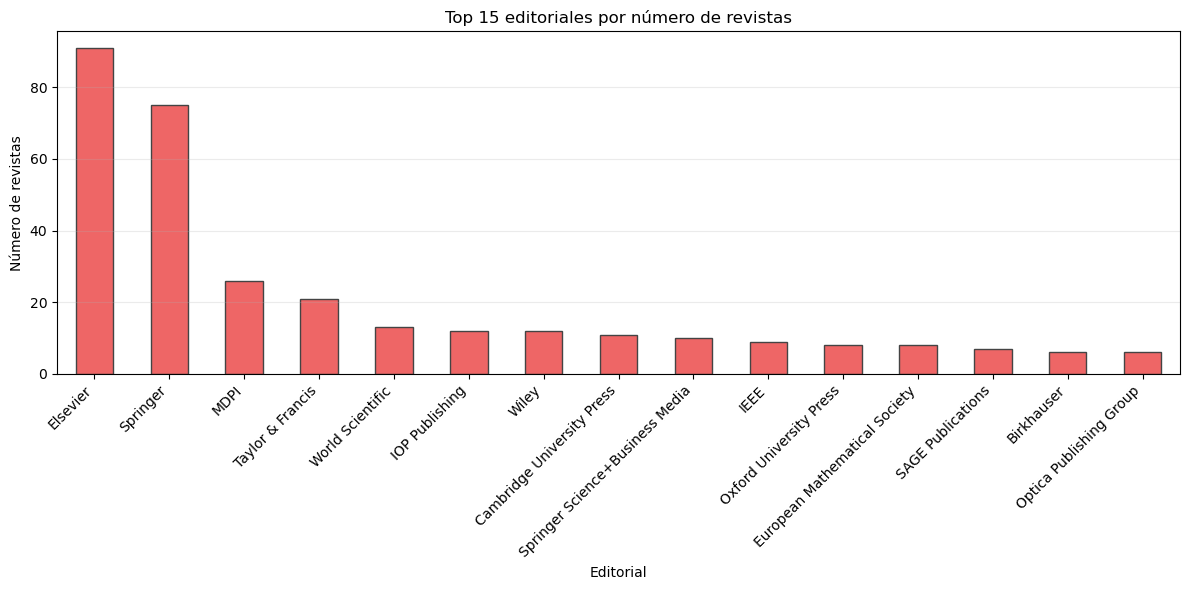

In [14]:
df_revistas = pd.read_csv(
    "C:/Code/tfg-gcd/Used-code/Revistas.csv",
    encoding="latin1",
    sep=";",
    header=None,
)

df_revistas_1 = df_revistas.iloc[:, 0].str.split(",", expand=True)
df_revistas_1 = df_revistas_1.iloc[:, :3]
df_revistas_1.columns = ["Revista", "Identificador", "Editorial"]

df_revistas_1["Editorial"] = (
    df_revistas_1["Editorial"]
    .str.strip()
    .str.strip('"')
    .str.strip("'")
)

conteo_editoriales = df_revistas_1["Editorial"].value_counts()

plt.figure(figsize=(12, 6))
conteo_editoriales.head(15).plot(
    kind="bar",
    color="#EE6666",
    edgecolor="#444444",
    linewidth=1
)
plt.title("Top 15 editoriales por número de revistas")
plt.xlabel("Editorial")
plt.ylabel("Número de revistas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.grid(axis="y", alpha=0.25)
plt.savefig("eda_top_editoriales.png", dpi=300, bbox_inches="tight")
plt.show()

#### Universidades

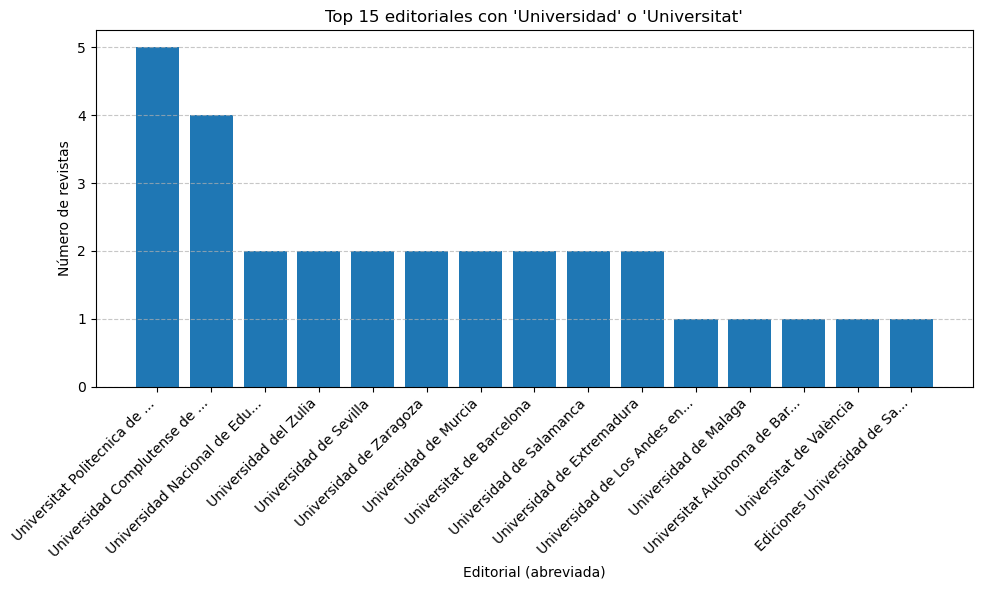

In [8]:
df_revistas_2 = df_revistas.iloc[:, 0].str.split(",", expand=True)
df_revistas_2.columns = ["Revista", "Identificador", "Editorial", "Extra"]

editoriales_universidad = df_revistas_2[
    df_revistas_2["Editorial"].str.contains("Universidad|Universitat", case=False, na=False)
]

conteo = editoriales_universidad["Editorial"].value_counts().head(15)

etiquetas = [e if len(e) <= 30 else e[:27] + "..." for e in conteo.index]

plt.figure(figsize=(10, 6))
plt.bar(etiquetas, conteo.values)
plt.title("Top 15 editoriales con 'Universidad' o 'Universitat'")
plt.xlabel("Editorial (abreviada)")
plt.ylabel("Número de revistas")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Investigadores

In [14]:
csvs_modificados = [
    "1ha_publicado_en_AlegreGC_editoriales.csv",
    "1ha_publicado_en_ArnauNAR_editoriales.csv",
    "1ha_publicado_en_ArroyoJM_editoriales.csv",
    "1ha_publicado_en_ArroyoJP_editoriales.csv",
    "1ha_publicado_en_BiviaC_editoriales.csv",
    "1ha_publicado_en_BonetSJ_editoriales.csv",
    "1ha_publicado_en_CalabuigRJM_editoriales.csv",
    "1ha_publicado_en_CobolloGC_editoriales.csv",
    "1ha_publicado_en_ConejeroJA_editoriales.csv",
    "1ha_publicado_en_FelipeRMJ_editoriales.csv",
    "1ha_publicado_en_FernandezCCPJ_editoriales.csv",
    "1ha_publicado_en_FerrerSA_editoriales.csv",
    "1ha_publicado_en_GarciaRLM_editoriales.csv",
    "1ha_publicado_en_GuijarroMF_editoriales.csv",
    "1ha_publicado_en_GuiraoSAJ_editoriales.csv",
    "1ha_publicado_en_HoyasCS_editoriales.csv",
    "1ha_publicado_en_IsidroSJJM_editoriales.csv",
    "1ha_publicado_en_JordaME_editoriales.csv",
    "1ha_publicado_en_JornetCD_editoriales.csv",
    "1ha_publicado_en_LazaroNM_editoriales.csv",
    "1ha_publicado_en_LopezMA_editoriales.csv",
    "1ha_publicado_en_LopezPM_editoriales.csv",
    "1ha_publicado_en_MartinezJF_editoriales.csv",
    "1ha_publicado_en_MartinezPA_editoriales.csv",
    "1ha_publicado_en_MartinezUMJ_editoriales.csv",
    "1ha_publicado_en_MilianEC_editoriales.csv",
    "1ha_publicado_en_MonserratDFJ_editoriales.csv",
    "1ha_publicado_en_MontesinosSV_editoriales.csv",
    "1ha_publicado_en_MorillasGS_editoriales.csv",
    "1ha_publicado_en_OrtizSVM_editoriales.csv",
    "1ha_publicado_en_PedrazaAMC_editoriales.csv",
    "1ha_publicado_en_PerisMA_editoriales.csv",
    "1ha_publicado_en_PesetMF_editoriales.csv",
    "1ha_publicado_en_PetrosyanL_editoriales.csv",
    "1ha_publicado_en_QuilisSA_editoriales.csv",
    "1ha_publicado_en_RodenasEF_editoriales.csv",
    "1ha_publicado_en_RodriguezLJ_editoriales.csv",
    "1ha_publicado_en_RomeroGV_editoriales.csv",
    "1ha_publicado_en_SanchezPEA_editoriales.csv",
    "1ha_publicado_en_SanchisLJM_editoriales.csv",
    "1ha_publicado_en_SevillaPP_editoriales.csv",
    "1ha_publicado_en_TiradoPP_editoriales.csv"
]

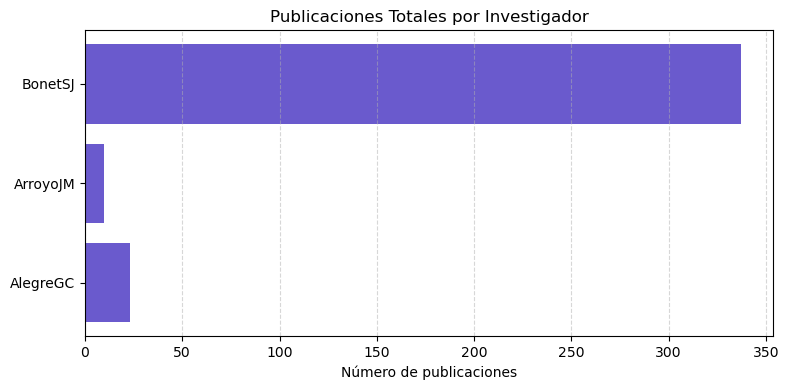

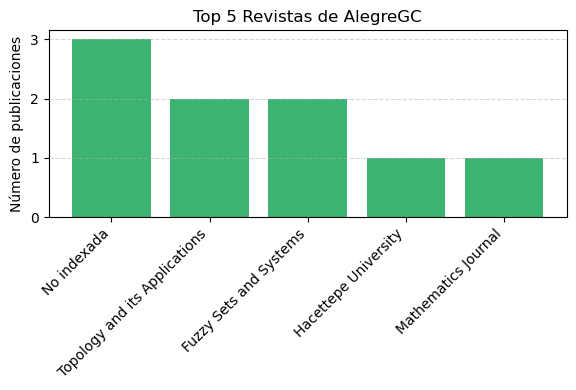

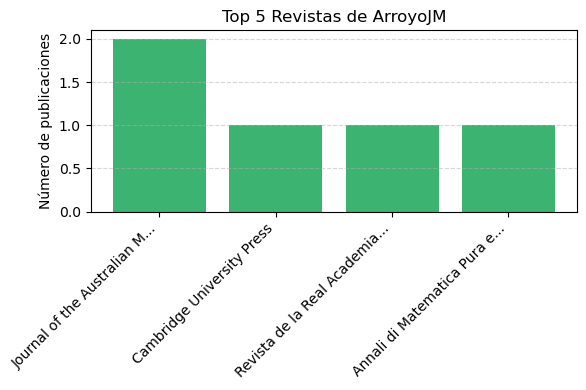

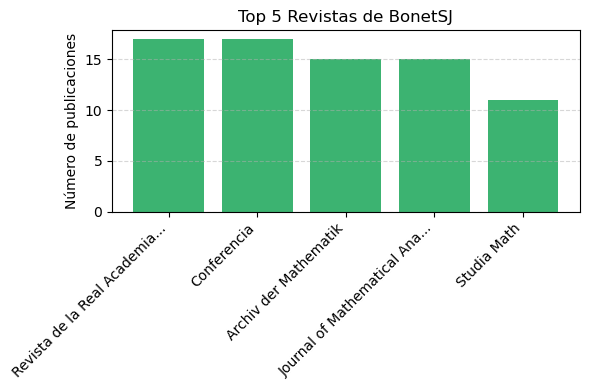

In [ ]:
investigadores_a_analizar = ["AlegreGC", "ArroyoJM", "BonetSJ"]

csvs_modificados = [
    "1ha_publicado_en_AlegreGC_editoriales.csv",
    "1ha_publicado_en_ArroyoJM_editoriales.csv",
    "1ha_publicado_en_BonetSJ_editoriales.csv"
]

publicaciones_totales = {}
editoriales_por_investigador = {}

for nombre in investigadores_a_analizar:
    archivo = f"1ha_publicado_en_{nombre}_editoriales.csv"
    if archivo in csvs_modificados:
        df = pd.read_csv(archivo, encoding="latin-1")
        publicaciones_totales[nombre] = len(df)
        top_editoriales = df["journal"].value_counts().head(5)
        editoriales_por_investigador[nombre] = top_editoriales

plt.figure(figsize=(8, 4))
plt.barh(list(publicaciones_totales.keys()), list(publicaciones_totales.values()), color="slateblue")
plt.title("Publicaciones Totales por Investigador")
plt.xlabel("Número de publicaciones")
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

for nombre, conteo in editoriales_por_investigador.items():
    plt.figure(figsize=(6, 4))
    
    # Acortar nombres largos
    etiquetas = [j if len(j) <= 30 else j[:27] + "..." for j in conteo.index]
    
    plt.bar(etiquetas, conteo.values, color="mediumseagreen")
    plt.title(f"Top 5 Revistas de {nombre}")
    plt.ylabel("Número de publicaciones")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()


### AREAS

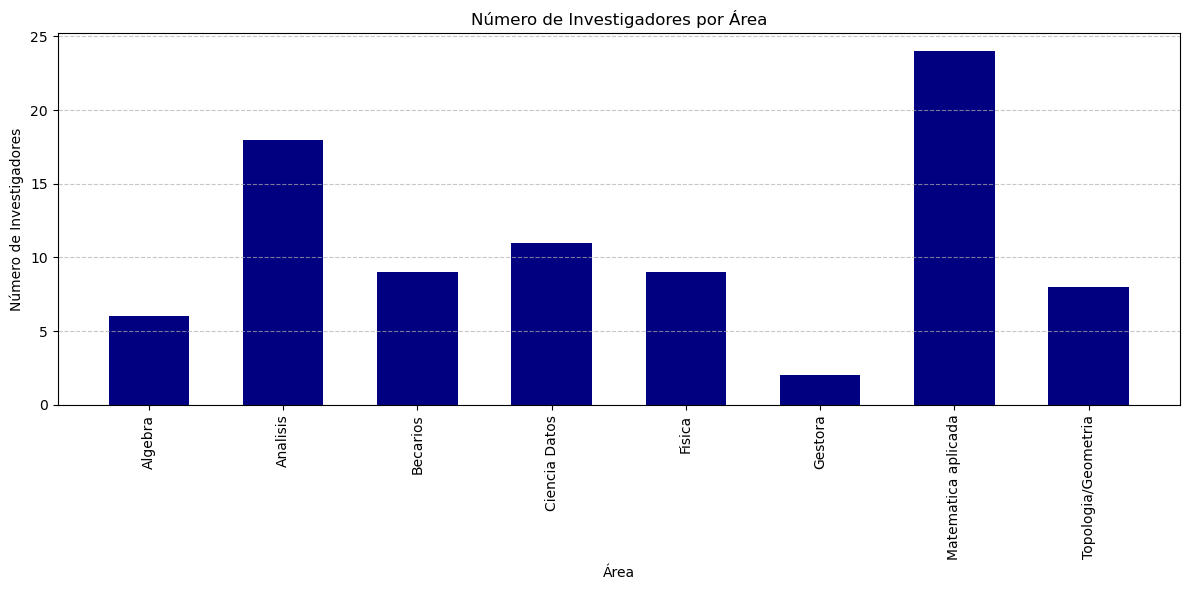

In [13]:
# Cargar datos
df_es_parte_de = pd.read_csv("es_parte_de_limpio_listas.csv", encoding="utf-8")
df_areas = pd.read_csv("Areas.csv", encoding="utf-8")
df_areas.columns = ["nombre_area", "id_area"]

# Separar listas en filas
df_es_parte_de["Areas"] = df_es_parte_de["Areas"].astype(str).str.strip("[]").str.replace("'", "").str.split(", ")
df_exploded = df_es_parte_de.explode("Areas")
df_exploded["Areas"] = df_exploded["Areas"].str.replace('"', '').str.strip()

# Hacer merge usando nombre del área
df_merged = df_exploded.merge(df_areas, left_on="Areas", right_on="nombre_area", how="left")

# Contar número de investigadores por área
conteo_areas = df_merged["nombre_area"].value_counts().sort_index()

# Graficar
plt.figure(figsize=(12, 6))
plt.bar(conteo_areas.index, conteo_areas.values, width=0.6, color='navy')
plt.xticks(rotation=90)
plt.title("Número de Investigadores por Área")
plt.xlabel("Área")
plt.ylabel("Número de Investigadores")
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### PROYECTOS - Exploración de estructura

In [10]:
import openpyxl
import glob
import os

# Ruta de los archivos de proyectos
carpeta_proyectos = "C:/Code/tfg-gcd/__Interface"

# Buscar todos los archivos ha_participado_en_*_FINAL.xlsx
archivos_proyectos = glob.glob(os.path.join(carpeta_proyectos, "ha_participado_en_*_FINAL.xlsx"))

print(f"Se encontraron {len(archivos_proyectos)} archivos de proyectos")
print(f"Primeros 5 archivos: {archivos_proyectos[:5]}")

# Explorar la estructura del primer archivo
if archivos_proyectos:
    primer_archivo = archivos_proyectos[0]
    print(f"\nExplorando: {os.path.basename(primer_archivo)}")
    
    # Leer con pandas para ver la estructura
    df_sample = pd.read_excel(primer_archivo)
    print(f"\nColumnas detectadas: {list(df_sample.columns)}")
    print(f"\nPrimeras filas:")
    print(df_sample.head())
    print(f"\nTipos de datos:")
    print(df_sample.dtypes)


Se encontraron 43 archivos de proyectos
Primeros 5 archivos: ['C:/Code/tfg-gcd/__Interface\\ha_participado_en_AlegreGC_FINAL.xlsx', 'C:/Code/tfg-gcd/__Interface\\ha_participado_en_ArnauNAR_FINAL.xlsx', 'C:/Code/tfg-gcd/__Interface\\ha_participado_en_ArroyoJM_FINAL.xlsx', 'C:/Code/tfg-gcd/__Interface\\ha_participado_en_ArroyoJP_FINAL.xlsx', 'C:/Code/tfg-gcd/__Interface\\ha_participado_en_AsensioLV_FINAL.xlsx']

Explorando: ha_participado_en_AlegreGC_FINAL.xlsx

Columnas detectadas: ['TÍTULO', 'AUTORES', 'FECHA', 'INDENTIFICADOR', 'INVESTIGADOR PRINCIPAL', 'AUTORES SIMPLIFICADO', 'Es_IP_Principal']

Primeras filas:
                                              TÍTULO  \
0  Topologia Para Computacion: Estructuras No Sim...   
1  Hiperespacios, Estructuras Difusas Y Asimetric...   
2  Metodos Topologicos En Hiperespacios Y Multifu...   
3  Integracion Bilineal, Medidas Vectoriales Y Es...   
4  Construcciones De Casi-Metricas Fuzzy, De Dist...   

                                          

In [11]:
# Verificar solo las columnas sin mostrar datos
if archivos_proyectos:
    primer_archivo = archivos_proyectos[0]
    df_sample = pd.read_excel(primer_archivo)
    
    print("COLUMNAS DETECTADAS:")
    for i, col in enumerate(df_sample.columns):
        print(f"  {i}: {col}")
    
    print(f"\nEjemplo de 2 filas (solo columnas relevantes):")
    # Mostrar solo las primeras 2 filas y algunas columnas
    cols_to_show = [col for col in df_sample.columns if 'título' in col.lower() or 'titulo' in col.lower() or 'date' in col.lower() or 'fecha' in col.lower() or 'year' in col.lower() or 'año' in col.lower()]
    if not cols_to_show:
        cols_to_show = df_sample.columns[:5].tolist()
    
    print(df_sample[cols_to_show].head(2))


COLUMNAS DETECTADAS:
  0: TÍTULO
  1: AUTORES
  2: FECHA
  3: INDENTIFICADOR
  4: INVESTIGADOR PRINCIPAL
  5: AUTORES SIMPLIFICADO
  6: Es_IP_Principal

Ejemplo de 2 filas (solo columnas relevantes):
                                              TÍTULO       FECHA
0  Topologia Para Computacion: Estructuras No Sim...  1996/09/11
1  Hiperespacios, Estructuras Difusas Y Asimetric...  2016/01/01


In [12]:
# ========== PROCESAMIENTO COMPLETO DE PROYECTOS ==========

import warnings
warnings.filterwarnings('ignore')

# 1. Leer todos los archivos de proyectos
carpeta_proyectos = "C:/Code/tfg-gcd/__Interface"
archivos_proyectos = glob.glob(os.path.join(carpeta_proyectos, "ha_participado_en_*_FINAL.xlsx"))

print("="*80)
print("PROCESAMIENTO DE PROYECTOS")
print("="*80)

dfs_proyectos = []
num_archivos = 0

for archivo in archivos_proyectos:
    try:
        df = pd.read_excel(archivo)
        dfs_proyectos.append(df)
        num_archivos += 1
    except Exception as e:
        print(f"Error al leer {os.path.basename(archivo)}: {e}")

df_proyectos_total = pd.concat(dfs_proyectos, ignore_index=True)

print(f"\n1. Número de archivos leídos: {num_archivos}")
print(f"   Archivos encontrados: {len(archivos_proyectos)}")

# 2. Detectar columnas
print(f"\n2. Columnas detectadas:")
columnas = list(df_proyectos_total.columns)
for col in columnas:
    print(f"   - {col}")

# 3. Información del dataset completo
print(f"\n3. Información del dataset:")
print(f"   Número total de registros: {len(df_proyectos_total)}")

# 4. Extraer año de la columna FECHA
df_proyectos_total['AÑO'] = pd.to_datetime(
    df_proyectos_total['FECHA'], 
    format='%Y/%m/%d',
    errors='coerce'
).dt.year

# Verificar si hay fechas inválidas
num_fechas_invalidas = df_proyectos_total['AÑO'].isna().sum()
if num_fechas_invalidas > 0:
    print(f"   ⚠ Advertencia: {num_fechas_invalidas} registros con fecha inválida")

# 5. Crear clave única de proyecto usando solo el título normalizado
df_proyectos_total['PROYECTO_UNICO'] = (
    df_proyectos_total['TÍTULO']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Para cada proyecto único, conservar el primer año disponible
df_proyectos_unicos = (
    df_proyectos_total
    .dropna(subset=['AÑO'])
    .sort_values('AÑO')
    .drop_duplicates(subset=['PROYECTO_UNICO'], keep='first')
)

print(f"\n4. Proyectos únicos:")
print(f"   Registros originales: {len(df_proyectos_total)}")
print(f"   Registros únicos (TÍTULO): {len(df_proyectos_unicos)}")

# 6. Contar proyectos por año
conteo_por_anio = df_proyectos_unicos['AÑO'].value_counts().sort_index()

print(f"\n5. Distribución de proyectos por año:")
print(conteo_por_anio.to_string())

print("\n" + "="*80)


PROCESAMIENTO DE PROYECTOS

1. Número de archivos leídos: 43
   Archivos encontrados: 43

2. Columnas detectadas:
   - TÍTULO
   - AUTORES
   - FECHA
   - INDENTIFICADOR
   - INVESTIGADOR PRINCIPAL
   - AUTORES SIMPLIFICADO
   - Es_IP_Principal

3. Información del dataset:
   Número total de registros: 576

4. Proyectos únicos:
   Registros originales: 576
   Registros únicos (TÍTULO): 281

5. Distribución de proyectos por año:
1991     1
1992     2
1994     1
1995     5
1996     4
1997     2
1998     5
1999     5
2000     4
2001     4
2002     9
2003     8
2004    14
2005    10
2006    14
2007    15
2008    14
2009    21
2010    17
2011    15
2012    19
2013    11
2014     1
2015    10
2016    11
2017     5
2018     4
2019     5
2020     4
2021     6
2022    12
2023    17
2024     6




✓ Imagen guardada en: C:/Code/tfg-gcd/Imgs/eda_proyectos_por_anio.png


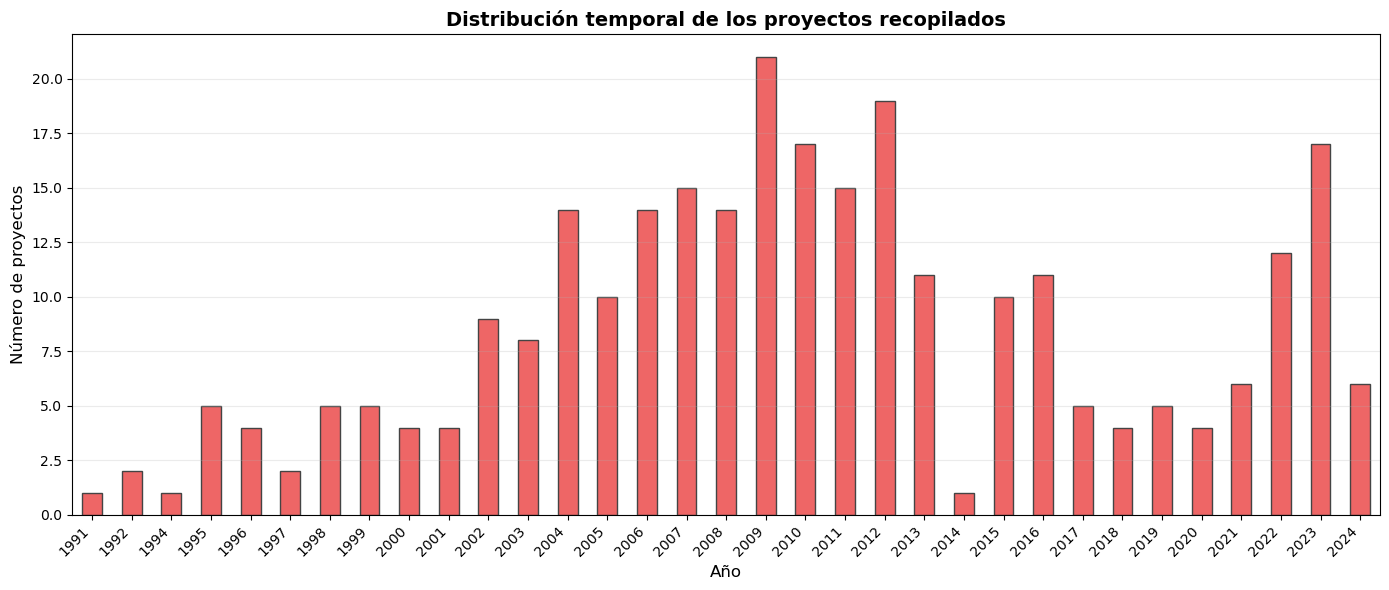


RESUMEN FINAL
✓ Se procesaron 43 archivos de proyectos
✓ Columnas utilizadas: TÍTULO, FECHA (extrayendo AÑO)
✓ Total de registros procesados: 576
✓ Proyectos únicos (TÍTULO + AÑO): 281
✓ Rango de años: 1991 - 2024
✓ Figura guardada: C:/Code/tfg-gcd/Imgs/eda_proyectos_por_anio.png


In [13]:
# ========== GENERACIÓN DEL GRÁFICO ==========

# Crear figura con especificaciones del usuario
plt.figure(figsize=(14, 6))
conteo_por_anio.plot(
    kind="bar",
    color="#EE6666",
    edgecolor="#444444",
    linewidth=1
)

plt.title("Distribución temporal de los proyectos recopilados", fontsize=14, fontweight='bold')
plt.xlabel("Año", fontsize=12)
plt.ylabel("Número de proyectos", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.grid(axis="y", alpha=0.25)

# Crear directorio si no existe
os.makedirs("C:/Code/tfg-gcd/Imgs", exist_ok=True)

# Guardar la imagen
ruta_salida = "C:/Code/tfg-gcd/Imgs/eda_proyectos_por_anio.png"
plt.savefig(ruta_salida, dpi=300, bbox_inches="tight")
print(f"\n✓ Imagen guardada en: {ruta_salida}")

plt.show()

print("\n" + "="*80)
print("RESUMEN FINAL")
print("="*80)
print(f"✓ Se procesaron {num_archivos} archivos de proyectos")
print(f"✓ Columnas utilizadas: TÍTULO, FECHA (extrayendo AÑO)")
print(f"✓ Total de registros procesados: {len(df_proyectos_total)}")
print(f"✓ Proyectos únicos (TÍTULO + AÑO): {len(df_proyectos_unicos)}")
print(f"✓ Rango de años: {int(conteo_por_anio.index.min())} - {int(conteo_por_anio.index.max())}")
print(f"✓ Figura guardada: {ruta_salida}")
print("="*80)
